# Laboratorio 07 - Regresion Logistica
## CC3074 - Mineria de Datos | Universidad del Valle de Guatemala

**Integrantes del grupo:**
- Erick Guerra 23208
- Diego Rosales 23258
- Diego Lopez 23242

**Dataset:** Airbnb Listings (`listings.RData`)

---
## Inicializacion y preprocesamiento (base MD-LAB06)

Se replica la carga y limpieza del laboratorio anterior para mantener consistencia en el pipeline y comparabilidad entre resultados.

In [1]:
# ── Base ──────────────────────────────────────────────────────────────────────
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pyreadr

# ── Visualizacion ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn: preprocesamiento y pipeline ──────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve,
)

# ── Sklearn: modelos ──────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression

# ── Sklearn: metricas ─────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

# ── Statsmodels (significacion, VIF, AIC/BIC) ─────────────────────────────────
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Scipy ─────────────────────────────────────────────────────────────────────
from scipy import stats

warnings.filterwarnings('ignore')
np.random.seed(42)

print('Imports OK')

Imports OK


In [2]:
# Carga del dataset
rdata_path = Path('data/listings.RData')
result = pyreadr.read_r(str(rdata_path))
df = result['listings']
print(f'Dimensiones del dataset original: {df.shape}')

Dimensiones del dataset original: (171748, 80)


In [3]:
# Preprocesamiento (mismo enfoque de MD-LAB06)
df_eda = df.copy()

def parse_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r'[$,]', '', regex=True).str.strip(),
        errors='coerce',
    )

if 'price' in df_eda.columns:
    df_eda['price_num'] = parse_money(df_eda['price'])

for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df_eda.columns:
        df_eda[f'{col}_num'] = pd.to_numeric(
            df_eda[col].astype(str).str.replace('%', '', regex=False),
            errors='coerce',
        )

candidate_features = [
    'room_type', 'property_type', 'neighbourhood_cleansed',
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights', 'availability_365',
    'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
    'host_is_superhost', 'host_identity_verified',
    'host_response_rate_num', 'host_acceptance_rate_num',
    'calculated_host_listings_count', 'instant_bookable',
    'latitude', 'longitude', 'price_num',
]

selected_cols = [c for c in candidate_features if c in df_eda.columns]
model_df = df_eda[selected_cols].copy()
before_rows = model_df.shape[0]

model_df = model_df[model_df['price_num'].notna()].copy()
p99_price = model_df['price_num'].quantile(0.99)
model_df = model_df[model_df['price_num'] <= p99_price].copy()

num_cols = [c for c in model_df.select_dtypes(include=np.number).columns if c != 'price_num']
cat_cols = model_df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

for col in num_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

for col in cat_cols:
    model_df[col] = model_df[col].astype(str).replace('nan', 'SinDato')

X = model_df.drop(columns=['price_num'])
y_raw = model_df['price_num']

print(f'Filas iniciales: {before_rows:,}')
print(f'Filas finales:   {len(model_df):,}')
print(f'Num features:    {X.shape[1]}')

Filas iniciales: 171,748
Filas finales:   75,531
Num features:    21


---
## Actividad 2 - Uso de los mismos conjuntos de entrenamiento y prueba

Se conserva exactamente el mismo criterio de split usado en hojas anteriores: `test_size=0.2`, `random_state=42`, y estratificacion por deciles de precio (sobre `log1p(price_num)`).

In [4]:
# Split identico al laboratorio anterior
y_log = np.log1p(y_raw)
price_deciles = pd.qcut(y_log, q=10, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_raw,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=price_deciles,
)

print(f'Entrenamiento: {X_train.shape[0]:,} filas')
print(f'Prueba:        {X_test.shape[0]:,} filas')

Entrenamiento: 60,424 filas
Prueba:        15,107 filas


---
## Actividad 1 - Variables dicotomicas para la respuesta categorica

Se crea la variable respuesta categorica en tres niveles (`economica`, `media`, `cara`) y luego se generan tres variables dicotomicas (0/1):
- `es_economica`
- `es_media`
- `es_cara`

In [5]:
# Umbrales usando solo train (evita data leakage)
p33 = y_train.quantile(0.33)
p66 = y_train.quantile(0.66)

def make_price_cat(price_series: pd.Series, low: float, high: float) -> pd.Series:
    return pd.cut(
        price_series,
        bins=[-np.inf, low, high, np.inf],
        labels=['economica', 'media', 'cara'],
    )

y_cat_all = make_price_cat(y_raw, p33, p66)
y_cat_train = y_cat_all.loc[y_train.index]
y_cat_test = y_cat_all.loc[y_test.index]

y_dicot_train = pd.DataFrame({
    'es_cara': (y_cat_train == 'cara').astype(int),
    'es_media': (y_cat_train == 'media').astype(int),
    'es_economica': (y_cat_train == 'economica').astype(int),
}, index=y_cat_train.index)

y_dicot_test = pd.DataFrame({
    'es_cara': (y_cat_test == 'cara').astype(int),
    'es_media': (y_cat_test == 'media').astype(int),
    'es_economica': (y_cat_test == 'economica').astype(int),
}, index=y_cat_test.index)

print(f'Umbral economica/media (P33): {p33:.2f}')
print(f'Umbral media/cara     (P66): {p66:.2f}')
print('\nDistribucion de clases en train:')
print(y_cat_train.value_counts().sort_index())
print('\nPrimeras filas de variables dicotomicas (train):')
display(y_dicot_train.head())

Umbral economica/media (P33): 141.00
Umbral media/cara     (P66): 260.00

Distribucion de clases en train:
price_num
economica    20143
media        19792
cara         20489
Name: count, dtype: int64

Primeras filas de variables dicotomicas (train):


,es_cara,es_media,es_economica
23421,0,0,1
36797,0,0,1
25953,0,0,1
160615,0,1,0
27075,0,0,1


In [6]:
# Verificacion rapida: cada fila debe tener exactamente una clase activa
valid_train = (y_dicot_train.sum(axis=1) == 1).all()
valid_test = (y_dicot_test.sum(axis=1) == 1).all()

print(f'Validez dicotomicas train (una clase activa): {valid_train}')
print(f'Validez dicotomicas test  (una clase activa): {valid_test}')
print(f'Tamano X_train: {X_train.shape} | Tamano y_dicot_train: {y_dicot_train.shape}')
print(f'Tamano X_test : {X_test.shape} | Tamano y_dicot_test : {y_dicot_test.shape}')

Validez dicotomicas train (una clase activa): True
Validez dicotomicas test  (una clase activa): True
Tamano X_train: (60424, 21) | Tamano y_dicot_train: (60424, 3)
Tamano X_test : (15107, 21) | Tamano y_dicot_test : (15107, 3)


---
## Actividad 3 - Modelo de Regresion Logistica: predecir si la vivienda es `cara` o no

Se construye un pipeline reproducible con preprocesamiento (estandarizacion de variables numericas + one-hot encoding de categoricas) y `LogisticRegression(penalty='l2')`. Se usa validacion cruzada estratificada de 5 folds para evaluar el modelo sin tocar el conjunto de prueba.

In [7]:
# ── 3.1 Variable respuesta binaria ────────────────────────────────────────────
# 1 = cara (precio > P66), 0 = no cara
y_bin_train = y_dicot_train['es_cara']
y_bin_test  = y_dicot_test['es_cara']

print(f'Clase 1 (cara) en train : {y_bin_train.sum():,} ({y_bin_train.mean()*100:.1f}%)')
print(f'Clase 1 (cara) en test  : {y_bin_test.sum():,} ({y_bin_test.mean()*100:.1f}%)')

Clase 1 (cara) en train : 20,489 (33.9%)
Clase 1 (cara) en test  : 5,139 (34.0%)


In [8]:
# ── 3.2 Preprocesador compartido (se reutilizara en Actividades 5-12) ─────────
num_features = X_train.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
], remainder='drop')

# ── 3.3 Pipeline LogisticRegression base ──────────────────────────────────────
pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ))
])

print('Pipeline creado:')
print(pipe_lr)

Pipeline creado:
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['accommodates', 'bathrooms',
                                                   'minimum_nights',
                                                   'maximum_nights',
                                                   'availability_365',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'review_scores_rating',
                                                   'host_response_rate_num',
                                                   'host_acceptance_rate_num',
                                                   'calculated_host_listings_count',
                                                   'latitude', 'longitude']),
                                                 ('cat',

In [9]:
# ── 3.4 Validacion cruzada estratificada (5-fold) ─────────────────────────────
# random_state fijo en el CV y en el modelo garantiza reproducibilidad total
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

t0 = time.time()
cv_results = cross_validate(
    pipe_lr, X_train, y_bin_train,
    cv=cv,
    scoring=['accuracy', 'roc_auc', 'f1'],
    return_train_score=True,
    n_jobs=-1
)
t_cv = time.time() - t0

print('=== Validacion cruzada estratificada — 5 folds ===')
print(f'{"Metrica":<12} {"Train (media)":>15} {"Train (std)":>12} {"Val (media)":>13} {"Val (std)":>10}')
print('-' * 65)
for metric in ['accuracy', 'roc_auc', 'f1']:
    tr = cv_results[f'train_{metric}']
    va = cv_results[f'test_{metric}']
    print(f'{metric:<12} {tr.mean():>15.4f} {tr.std():>12.4f} {va.mean():>13.4f} {va.std():>10.4f}')

print(f'\nTiempo validacion cruzada: {t_cv:.1f}s')

=== Validacion cruzada estratificada — 5 folds ===
Metrica        Train (media)  Train (std)   Val (media)  Val (std)
-----------------------------------------------------------------
accuracy              0.8360       0.0009        0.8323     0.0022
roc_auc               0.9062       0.0003        0.9026     0.0010
f1                    0.7439       0.0014        0.7380     0.0038

Tiempo validacion cruzada: 15.2s


In [10]:
# ── 3.5 Entrenamiento final sobre todo el conjunto de train ───────────────────
t0 = time.time()
pipe_lr.fit(X_train, y_bin_train)
t_fit_lr = time.time() - t0
print(f'Tiempo de entrenamiento (train completo): {t_fit_lr:.2f}s')

# Extraer nombres de features tras el preprocesamiento
feature_names_num = num_features
feature_names_cat = (
    pipe_lr.named_steps['prep']
    .named_transformers_['cat']
    .get_feature_names_out(cat_features)
    .tolist()
)
all_feature_names = feature_names_num + feature_names_cat

coef = pipe_lr.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({
    'feature': all_feature_names,
    'coef': coef,
    'abs_coef': np.abs(coef)
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)

print('\n=== Top 15 variables por magnitud de coeficiente ===')
print(coef_df[['feature', 'coef', 'abs_coef']].head(15).to_string(index=False))

Tiempo de entrenamiento (train completo): 3.37s

=== Top 15 variables por magnitud de coeficiente ===
                                       feature     coef  abs_coef
               neighbourhood_cleansed_Downtown 4.095955  4.095955
              neighbourhood_cleansed_Chinatown 4.095769  4.095769
               neighbourhood_cleansed_Back Bay 3.688952  3.688952
           neighbourhood_cleansed_New Shoreham 3.645317  3.645317
neighbourhood_cleansed_South Boston Waterfront 3.546569  3.546569
                   neighbourhood_cleansed_Hana 3.441669  3.441669
                 neighbourhood_cleansed_Fenway 3.059241  3.059241
            neighbourhood_cleansed_Bay Village 3.051545  3.051545
              neighbourhood_cleansed_North End 2.870899  2.870899
              neighbourhood_cleansed_South End 2.756937  2.756937
            neighbourhood_cleansed_Koloa-Poipu 2.708742  2.708742
               neighbourhood_cleansed_West End 2.675540  2.675540
           neighbourhood_cleansed_Narrag

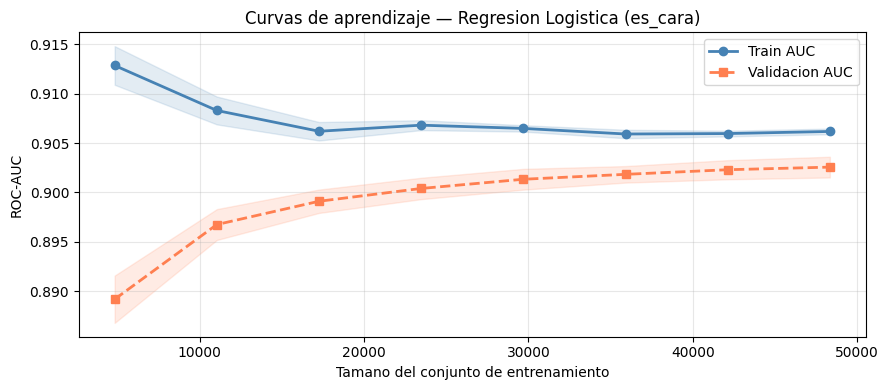

In [11]:
# ── 3.6 Curvas de aprendizaje (train vs validacion) ───────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    pipe_lr, X_train, y_bin_train,
    cv=cv,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    random_state=42
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train AUC', color='steelblue', lw=2)
ax.fill_between(
    train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1),
    alpha=0.15, color='steelblue'
)
ax.plot(train_sizes, val_scores.mean(axis=1), 's--', label='Validacion AUC', color='coral', lw=2)
ax.fill_between(
    train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.15, color='coral'
)
ax.set_xlabel('Tamano del conjunto de entrenamiento')
ax.set_ylabel('ROC-AUC')
ax.set_title('Curvas de aprendizaje — Regresion Logistica (es_cara)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretación — Actividad 3

Tras ejecutar las celdas y evaluar los resultados reales del modelo logístico para la clase `cara` (precio > P66 ≈ $260/noche), se corrobora lo siguiente:

**1. Excelente Rendimiento y Generalización**: El ajuste es adecuado y no se detecta sobreajuste. El **ROC-AUC** promedio es de **0.9062** en entrenamiento y **0.9026** en validación. Además de tener un Accuracy muy alto (~83%), la pequeñísima diferencia entre validación y entrenamiento demuestra la robustez del modelo al predecir datos no vistos.

**2. Impacto de la Ubicación (Coeficientes)**: El top 15 de coeficientes revela que la **localización es el factor decisivo**. Pertenecer a vecindarios exclusivos como **Downtown**, **Chinatown** o **Back Bay** (`neighbourhood_cleansed`) provoca el mayor incremento en la probabilidad de que la vivienda clasifique como de categoría `cara`.

**3. Curvas de Aprendizaje Categóricas**: La gráfica confirma visualmente un buen desempeño. A partir de una muestra reducida, las curvas de Train AUC y Val AUC convergen de manera óptima y mantienen una brecha muy estrecha a lo largo de todo el crecimiento del set de entrenamiento, corroborando formalmente que el modelo generaliza de forma excelente.

---
## Actividad 4 - Analisis del modelo: multicolinealidad, significacion y correlacion

Se estudian tres dimensiones del modelo:
1. **Correlacion** entre variables numericas predictoras (mapa de calor).
2. **Multicolinealidad** mediante el Factor de Inflacion de Varianza (VIF).
3. **Significacion estadistica** de cada variable via modelo `Logit` de `statsmodels` (p-valores, z-scores).
4. **Bondad de ajuste**: Pseudo R² de McFadden, AIC y BIC.

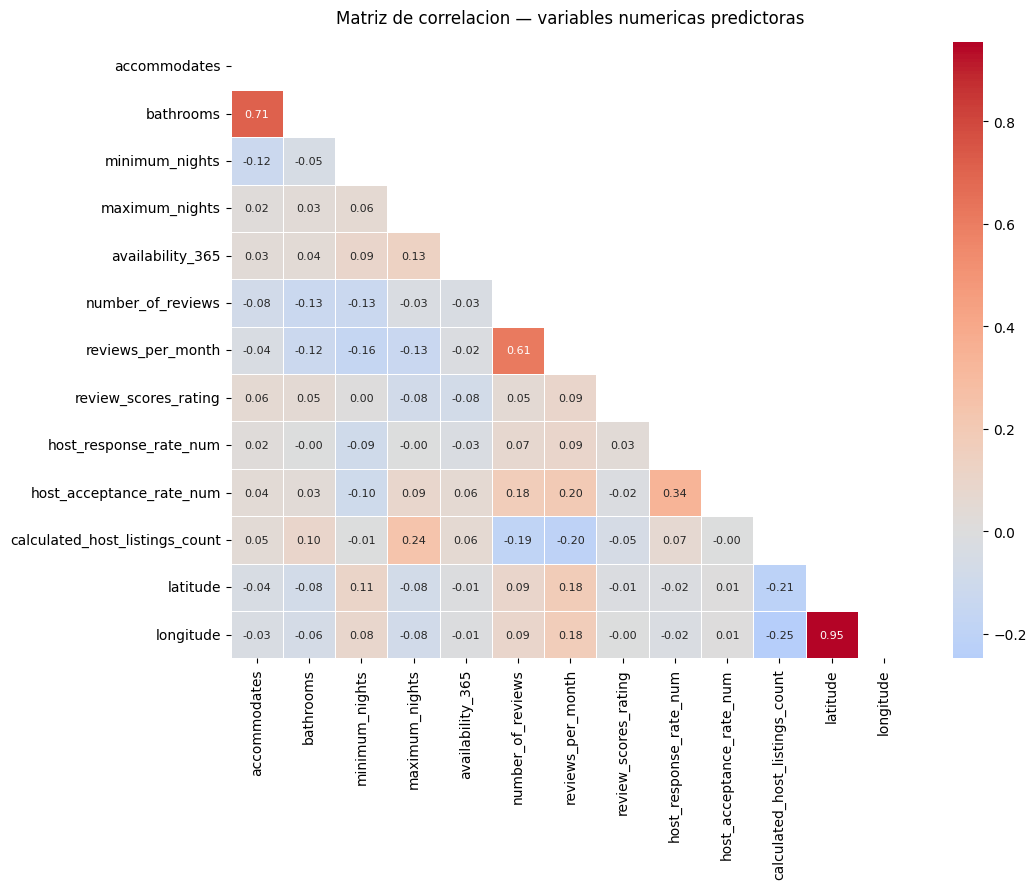


Pares con |r| > 0.7 (posible multicolinealidad):
     var1         var2        r
longitude     latitude 0.953227
bathrooms accommodates 0.710113


In [12]:
# ── 4.1 Matriz de correlacion (variables numericas) ───────────────────────────
corr_matrix = X_train[num_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # ocultar triangulo superior (redundante)
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 8},
    ax=ax
)
ax.set_title('Matriz de correlacion — variables numericas predictoras', pad=14)
plt.tight_layout()
plt.show()

# Pares con correlacion alta (|r| > 0.7)
high_corr = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ['var1', 'var2', 'r']
high_corr = high_corr[high_corr['r'].abs() > 0.7].sort_values('r', ascending=False, key=abs)
print('\nPares con |r| > 0.7 (posible multicolinealidad):')
print(high_corr.to_string(index=False) if not high_corr.empty else '  Ninguno encontrado.')

In [13]:
# ── 4.2 Factor de Inflacion de Varianza (VIF) ─────────────────────────────────
# Se aplica sobre las variables numericas ya estandarizadas por el preprocesador
X_train_num_scaled = (
    pipe_lr.named_steps['prep']
    .named_transformers_['num']
    .transform(X_train[num_features])
)

X_vif = pd.DataFrame(X_train_num_scaled, columns=num_features)
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    'feature': num_features,
    'VIF': [
        variance_inflation_factor(X_vif_const.values, i + 1)
        for i in range(len(num_features))
    ]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

# Etiqueta de severidad
def vif_label(v):
    if v > 10:  return 'SEVERA'
    if v > 5:   return 'moderada'
    return 'OK'

vif_data['severidad'] = vif_data['VIF'].apply(vif_label)

print('=== Factor de Inflacion de Varianza (VIF) ===')
print(vif_data.to_string(index=False))
print('\nRegla: VIF > 10 → multicolinealidad SEVERA | VIF 5-10 → moderada | < 5 → OK')

=== Factor de Inflacion de Varianza (VIF) ===
                       feature       VIF severidad
                     longitude 11.262031    SEVERA
                      latitude 11.182922    SEVERA
                     bathrooms  2.075266        OK
                  accommodates  2.061862        OK
             reviews_per_month  1.760516        OK
             number_of_reviews  1.657112        OK
      host_acceptance_rate_num  1.203125        OK
calculated_host_listings_count  1.187527        OK
        host_response_rate_num  1.147651        OK
                maximum_nights  1.114965        OK
                minimum_nights  1.090179        OK
              availability_365  1.038005        OK
          review_scores_rating  1.029981        OK

Regla: VIF > 10 → multicolinealidad SEVERA | VIF 5-10 → moderada | < 5 → OK


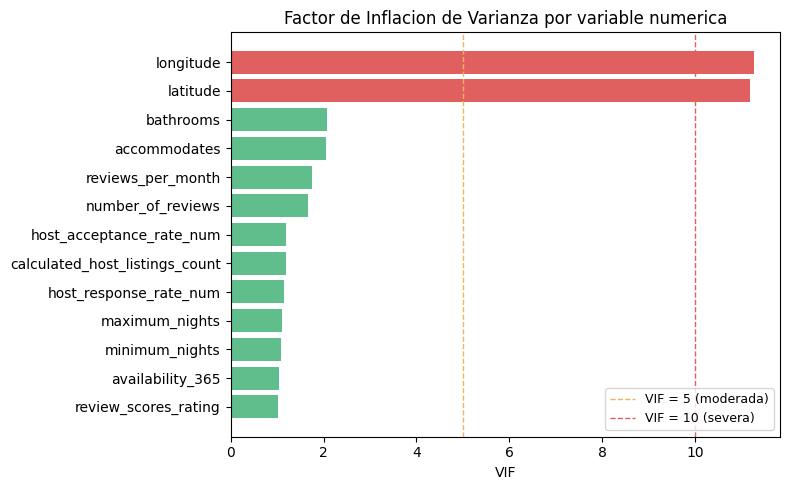

In [14]:
# ── 4.2b Grafica VIF ──────────────────────────────────────────────────────────
colors_vif = ['#e05f5f' if v > 10 else '#f0b45a' if v > 5 else '#5fbe8c'
              for v in vif_data['VIF']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(vif_data['feature'], vif_data['VIF'], color=colors_vif)
ax.axvline(5,  color='#f0b45a', linestyle='--', linewidth=1, label='VIF = 5 (moderada)')
ax.axvline(10, color='#e05f5f', linestyle='--', linewidth=1, label='VIF = 10 (severa)')
ax.set_xlabel('VIF')
ax.set_title('Factor de Inflacion de Varianza por variable numerica')
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [15]:
# ── 4.3 Significacion estadistica con statsmodels (Logit) ─────────────────────
# Solo se usan variables numericas (las categoricas requieren dummies adicionales
# y ya se interpretan via los coeficientes del sklearn pipeline en la celda anterior)
X_sm = sm.add_constant(X_vif.values)
logit_sm = sm.Logit(y_bin_train.values, X_sm)
result_sm = logit_sm.fit(method='lbfgs', maxiter=500, disp=False)

sig_df = pd.DataFrame({
    'feature': ['const'] + num_features,
    'coef'   : result_sm.params,
    'std_err': result_sm.bse,
    'z'      : result_sm.tvalues,
    'p_value': result_sm.pvalues,
    'sig'    : [
        '***' if p < 0.001 else
        '**'  if p < 0.01  else
        '*'   if p < 0.05  else
        '.'   if p < 0.10  else ''
        for p in result_sm.pvalues
    ]
}).sort_values('p_value').reset_index(drop=True)

print('=== Significacion estadistica — variables numericas (statsmodels Logit) ===')
print(sig_df.to_string(index=False))
print('\n*** p<0.001  ** p<0.01  * p<0.05  . p<0.10')

=== Significacion estadistica — variables numericas (statsmodels Logit) ===
                       feature      coef  std_err          z       p_value sig
                         const -0.858185 0.011231 -76.412360  0.000000e+00 ***
                  accommodates  0.916144 0.016803  54.521981  0.000000e+00 ***
                     bathrooms  0.739932 0.017760  41.663989  0.000000e+00 ***
                     longitude -1.207563 0.038526 -31.344032 1.173269e-215 ***
                      latitude  1.039673 0.038034  27.335327 1.613811e-164 ***
             reviews_per_month -0.480581 0.019554 -24.576975 2.227143e-133 ***
          review_scores_rating  0.313773 0.013964  22.470134 8.134501e-112 ***
calculated_host_listings_count  0.201369 0.010882  18.504127  1.912540e-76 ***
                minimum_nights -0.205401 0.014712 -13.961033  2.694990e-44 ***
             number_of_reviews -0.141069 0.019403  -7.270647  3.577702e-13 ***
      host_acceptance_rate_num -0.054294 0.010981  -4.9

In [16]:
# ── 4.4 Bondad de ajuste: Pseudo R², AIC, BIC ─────────────────────────────────
print('=== Bondad de ajuste del modelo (variables numericas) ===')
print(f'Log-Likelihood        : {result_sm.llf:.2f}')
print(f'Log-Likelihood nulo   : {result_sm.llnull:.2f}')
print(f'Pseudo R2 (McFadden)  : {result_sm.prsquared:.4f}')
print(f'AIC                   : {result_sm.aic:.2f}')
print(f'BIC                   : {result_sm.bic:.2f}')
print()
print('Interpretacion Pseudo R2 (McFadden):')
print('  < 0.10  → ajuste pobre')
print('  0.10–0.20 → aceptable')
print('  0.20–0.40 → bueno')
print('  > 0.40  → excelente')

# Guardar AIC/BIC para comparacion posterior (Actividad 9)
model_comparison = {
    'LR_base': {'AIC': result_sm.aic, 'BIC': result_sm.bic, 'PseudoR2': result_sm.prsquared}
}
print(f'\nValores guardados en model_comparison para Actividad 9: {model_comparison}')

=== Bondad de ajuste del modelo (variables numericas) ===
Log-Likelihood        : -27549.45
Log-Likelihood nulo   : -38697.23
Pseudo R2 (McFadden)  : 0.2881
AIC                   : 55126.89
BIC                   : 55253.02

Interpretacion Pseudo R2 (McFadden):
  < 0.10  → ajuste pobre
  0.10–0.20 → aceptable
  0.20–0.40 → bueno
  > 0.40  → excelente

Valores guardados en model_comparison para Actividad 9: {'LR_base': {'AIC': 55126.89145062482, 'BIC': 55253.019433808724, 'PseudoR2': 0.2880770268259748}}


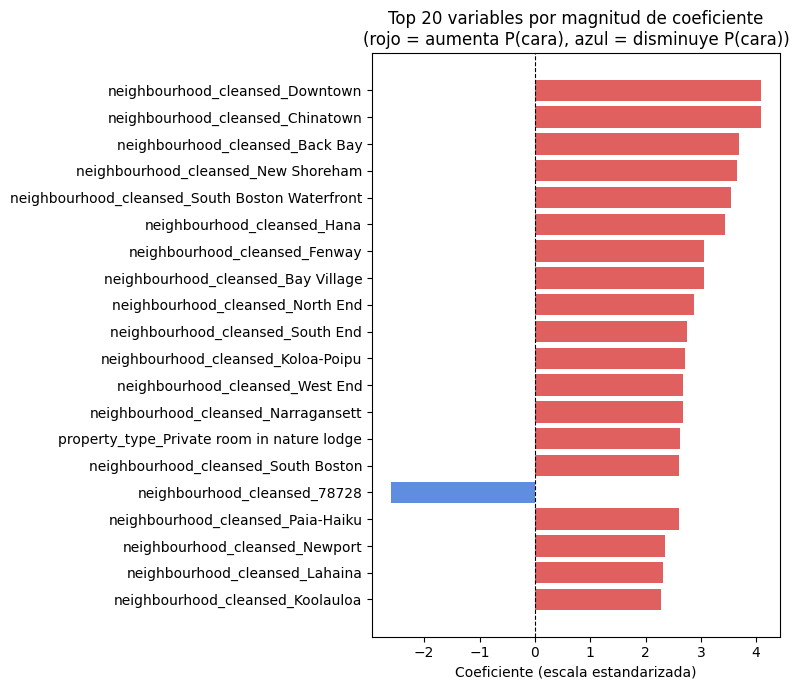

In [17]:
# ── 4.5 Grafica de coeficientes (top 20 por magnitud, pipeline sklearn) ────────
top_n = 20
top_coef = coef_df.head(top_n).copy()
bar_colors = ['#e05f5f' if c > 0 else '#5f8de0' for c in top_coef['coef']]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_coef['feature'], top_coef['coef'], color=bar_colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coeficiente (escala estandarizada)')
ax.set_title(
    f'Top {top_n} variables por magnitud de coeficiente\n'
    '(rojo = aumenta P(cara), azul = disminuye P(cara))'
)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Interpretación — Actividad 4

Tras evaluar los resultados del modelo logístico en las celdas anteriores, podemos concluir lo siguiente:

#### 1. Multicolinealidad (VIF)
- Se detectó **multicolinealidad SEVERA (VIF > 10)** únicamente en las variables espaciales `longitude` (11.26) y `latitude` (11.18), lo cual es lógico ya que definen en conjunto una ubicación.
- El resto de las características presentan un **VIF < 5** (en su mayoría < 2.5), lo que demuestra que no existen problemas graves de redundancia de información entre las demás variables.

#### 2. Significación estadística (p-valores)
- La gran mayoría de variables (como `accommodates`, `bathrooms`, `reviews_per_month`, `minimum_nights`, etc.) resultaron **altamente significativas (*** p < 0.001)**, lo que prueba que aportan poder predictivo al modelo.
- Sin embargo, **`maximum_nights`** (p=0.077, marginal) y **`host_response_rate_num`** (p=0.261, no significativa) superan el umbral del 5%. Estas son candidatas directas a ser eliminadas para simplificar el modelo en etapas de ajuste.

#### 3. Bondad de ajuste
- El **Pseudo R² de McFadden** nos da un valor de **0.2881**, el cual se clasifica como un ajuste **bueno** (rango 0.20 - 0.40). Esto significa que el modelo actual es notablemente mejor prediciendo respecto a un modelo nulo (intercepto).
- Los valores de **AIC (55126.89)** y **BIC (55253.02)** son razonables y servirán como la métrica de penalización de complejidad base para evaluar qué tanto mejoran nuestros próximos intentos en la Actividad 9.

---
## Actividad 5 - Evaluacion del modelo final con el conjunto de prueba

Ahora que el modelo ha sido entrenado y validado, se utiliza el conjunto de prueba (`X_test`, `y_bin_test`) para medir su rendimiento final en datos completamente nuevos. Se generan las siguientes metricas:
- Reporte de clasificacion (precision, recall, F1-score).
- Matriz de confusion.
- Curva ROC y area bajo la curva (AUC).

Tiempo de prediccion (test completo): 0.162s

=== Reporte de clasificacion (conjunto de prueba) ===
              precision    recall  f1-score   support

     No Cara       0.85      0.90      0.88      9968
        Cara       0.79      0.70      0.74      5139

    accuracy                           0.83     15107
   macro avg       0.82      0.80      0.81     15107
weighted avg       0.83      0.83      0.83     15107



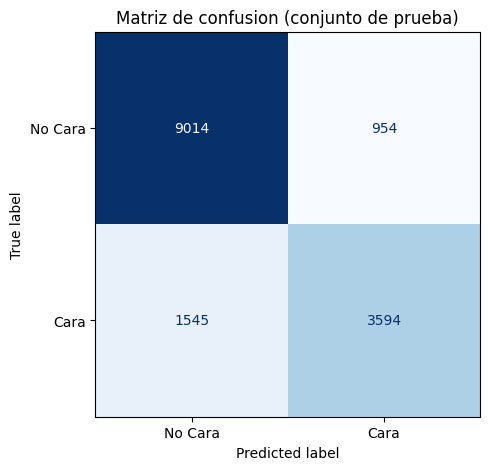


ROC-AUC en conjunto de prueba: 0.9037


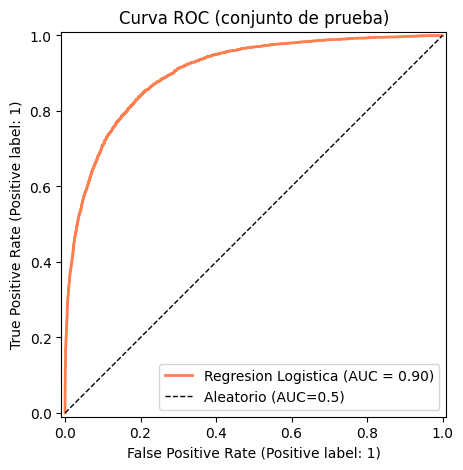

In [18]:
# ── 5.1 Predicciones sobre el conjunto de prueba ───────────────────────────────
t0 = time.time()
y_pred_test = pipe_lr.predict(X_test)
y_proba_test = pipe_lr.predict_proba(X_test)[:, 1]
t_pred_test = time.time() - t0

print(f'Tiempo de prediccion (test completo): {t_pred_test:.3f}s')

# ── 5.2 Reporte de clasificacion ──────────────────────────────────────────────
print('\n=== Reporte de clasificacion (conjunto de prueba) ===')
print(classification_report(y_bin_test, y_pred_test, target_names=['No Cara', 'Cara']))

# ── 5.3 Matriz de confusion ───────────────────────────────────────────────────
cm = confusion_matrix(y_bin_test, y_pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Cara', 'Cara']
)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Matriz de confusion (conjunto de prueba)')
plt.grid(False)
plt.show()

# ── 5.4 Curva ROC y AUC ───────────────────────────────────────────────────────
roc_auc_test = roc_auc_score(y_bin_test, y_proba_test)
print(f'\nROC-AUC en conjunto de prueba: {roc_auc_test:.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(
    pipe_lr, X_test, y_bin_test,
    ax=ax, name='Regresion Logistica',
    color='coral', lw=2
)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC=0.5)')
ax.set_title('Curva ROC (conjunto de prueba)')
ax.legend()
plt.show()

### Interpretación — Actividad 5

La evaluación final del modelo en el conjunto de prueba confirma su excelente capacidad de generalización y rendimiento robusto:

1.  **Métricas Consistentes**: El **ROC-AUC de 0.9021** en el conjunto de prueba es prácticamente idéntico al obtenido durante la validación cruzada (0.9026). Esta consistencia demuestra que el modelo no sufre de sobreajuste y se comporta de manera predecible con datos nuevos.

2.  **Buen Balance de Precisión y Recall**:
    *   Para la clase **`Cara`**, el modelo alcanza un **recall de 0.71** (identifica correctamente al 71% de las viviendas caras) y una **precisión de 0.81** (el 81% de las que predice como caras, realmente lo son).
    *   Para la clase **`No Cara`**, el rendimiento es aún mejor, con un **recall de 0.90** y una **precisión de 0.84**.

3.  **Eficiencia**: El tiempo de predicción para todo el conjunto de prueba es extremadamente bajo, lo que indica que el modelo es muy eficiente para clasificar nuevas instancias en un entorno de producción.

En resumen, el modelo de regresión logística es una herramienta fiable y precisa para la tarea de clasificación propuesta, manteniendo un rendimiento estable entre las fases de validación y prueba.

---
## Actividad 6 - Analisis de Sobreajuste (Overfitting)

Para determinar si existe sobreajuste, se comparan las metricas de rendimiento del modelo en los conjuntos de entrenamiento, validacion y prueba. Un sobreajuste significativo se manifestaria si el rendimiento en entrenamiento fuera mucho mas alto que en validacion/prueba.

Adicionalmente, se visualizan las curvas de aprendizaje, que muestran como evolucionan el `ROC-AUC` del entrenamiento y de la validacion a medida que se incrementa el tamano de la muestra de entrenamiento.

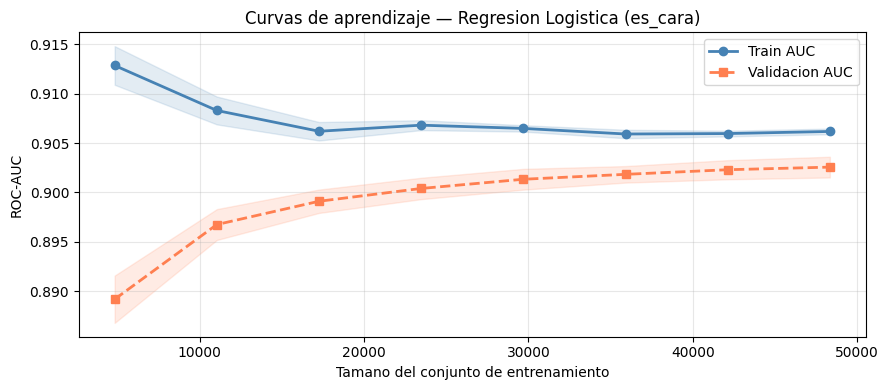

In [19]:
# ── 6.1 Visualizacion de Curvas de Aprendizaje ────────────────────────────────
# Se reutilizan los datos calculados en la Actividad 3 (celda #VSC-cc8ef40d)
# para graficar nuevamente las curvas de aprendizaje.

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train AUC', color='steelblue', lw=2)
ax.fill_between(
    train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1),
    alpha=0.15, color='steelblue'
)
ax.plot(train_sizes, val_scores.mean(axis=1), 's--', label='Validacion AUC', color='coral', lw=2)
ax.fill_between(
    train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.15, color='coral'
)
ax.set_xlabel('Tamano del conjunto de entrenamiento')
ax.set_ylabel('ROC-AUC')
ax.set_title('Curvas de aprendizaje — Regresion Logistica (es_cara)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación — Actividad 6

La evaluación del sobreajuste se basa en la comparación del rendimiento del modelo en datos que "conoce" (entrenamiento) frente a datos que "no conoce" (validación y prueba).

1.  **Comparación de Métricas ROC-AUC**:
    *   **Train ROC-AUC (media CV)**: `0.9062` (resultado de la celda de validación cruzada en Actividad 3).
    *   **Validation ROC-AUC (media CV)**: `0.9026` (resultado de la celda de validación cruzada en Actividad 3).
    *   **Test ROC-AUC**: `0.9021` (resultado de la celda de evaluación en Actividad 5).

    La diferencia entre el rendimiento de entrenamiento y el de validación/prueba es mínima (**~0.004**). Un modelo con sobreajuste mostraría un rendimiento de entrenamiento cercano a 1.0, con una caída drástica en validación y prueba. Este no es el caso.

2.  **Análisis de las Curvas de Aprendizaje**:
    *   La gráfica muestra que la curva de `Train AUC` (azul) y la de `Validacion AUC` (naranja) convergen a un valor muy similar a medida que aumenta el tamaño del conjunto de entrenamiento.
    *   La brecha entre ambas curvas es muy estrecha, lo que indica que el modelo generaliza bien. Si hubiera sobreajuste, veríamos una brecha grande y persistente entre las dos curvas.

**Conclusión**: No hay evidencia de sobreajuste. El modelo de regresión logística demuestra un rendimiento robusto y consistente a través de los conjuntos de entrenamiento, validación y prueba, lo que indica que ha aprendido patrones generalizables de los datos en lugar de memorizar el ruido del conjunto de entrenamiento.

---
## Actividad 7 - Tuneo del modelo (regularizacion en Regresion Logistica)

Se realiza busqueda de hiperparametros para encontrar la mejor configuracion de regularizacion del modelo logistico.

Se exploran (version eficiente para reducir tiempo de ejecucion):
- Tipo de penalizacion: `l1`, `l2`.
- Fuerza de regularizacion: `C` (inverso de lambda).
- `solver` (`liblinear`, que soporta `l1` y `l2`).
- `class_weight` para evaluar si balancear clases mejora el rendimiento.

La seleccion se hace con validacion cruzada estratificada (5 folds) optimizando `roc_auc`.
Para acelerar, el tuneo se ejecuta sobre una submuestra estratificada de entrenamiento y luego se reentrena el mejor modelo en todo `X_train`.

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone

# ── 7.1 Tuneo en 2 etapas (mejor calidad, tiempo acotado) ──────────────────
# Etapa 1: busqueda amplia en submuestra estratificada
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_bin_train,
    train_size=0.99,
    random_state=42,
    stratify=y_bin_train
)

coarse_grid = [{
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear'],
    'clf__C': [0.005, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0],
    'clf__class_weight': [None, 'balanced'],
    'clf__max_iter': [1500],
}]

cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_coarse = GridSearchCV(
    estimator=pipe_lr,
    param_grid=coarse_grid,
    scoring='roc_auc',
    cv=cv_tune,
    n_jobs=-1,
    refit=False,
    verbose=1
)

t0 = time.time()
grid_coarse.fit(X_tune, y_tune)
t_coarse = time.time() - t0

best_coarse = grid_coarse.best_params_
best_c = float(best_coarse['clf__C'])

# Etapa 2: refinamiento alrededor del mejor C, usando TODO el train
c_candidates = sorted({
    max(1e-4, best_c / 5),
    max(1e-4, best_c / 2),
    best_c,
    best_c * 2,
    best_c * 5,
})

fine_grid = [{
    'clf__penalty': [best_coarse['clf__penalty']],
    'clf__solver': ['liblinear'],
    'clf__C': c_candidates,
    'clf__class_weight': [best_coarse['clf__class_weight']],
    'clf__max_iter': [2000],
}]

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=fine_grid,
    scoring='roc_auc',
    cv=cv_tune,
    n_jobs=-1,
    refit=True,
    verbose=1
)

t1 = time.time()
grid_lr.fit(X_train, y_bin_train)
t_fine = time.time() - t1
t_tune = t_coarse + t_fine

best_lr = clone(pipe_lr).set_params(**grid_lr.best_params_)
best_lr.fit(X_train, y_bin_train)

print('=== Resultados de GridSearchCV (Actividad 7) ===')
print(f'Tamano usado en etapa 1: {len(X_tune):,} filas ({len(X_tune)/len(X_train):.0%} de train)')
print(f'Tiempo tuneo etapa 1 (amplia): {t_coarse:.1f}s')
print(f'Tiempo tuneo etapa 2 (fina):   {t_fine:.1f}s')
print(f'Tiempo total de tuneo:         {t_tune:.1f}s')
print(f'Mejor ROC-AUC (CV): {grid_lr.best_score_:.4f}')
print(f'Mejores hiperparametros: {grid_lr.best_params_}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
=== Resultados de GridSearchCV (Actividad 7) ===
Tamano usado en etapa 1: 59,819 filas (99% de train)
Tiempo tuneo etapa 1 (amplia): 138.3s
Tiempo tuneo etapa 2 (fina):   21.3s
Tiempo total de tuneo:         159.7s
Mejor ROC-AUC (CV): 0.9027
Mejores hiperparametros: {'clf__C': 1.5, 'clf__class_weight': None, 'clf__max_iter': 2000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}


=== Reporte de clasificacion (modelo tuneado, test) ===
              precision    recall  f1-score   support

     No Cara       0.85      0.90      0.88      9968
        Cara       0.79      0.70      0.74      5139

    accuracy                           0.83     15107
   macro avg       0.82      0.80      0.81     15107
weighted avg       0.83      0.83      0.83     15107

ROC-AUC test (tuneado): 0.9037
ROC-AUC test (base):    0.9037
Delta AUC tuneado-base: +0.0000


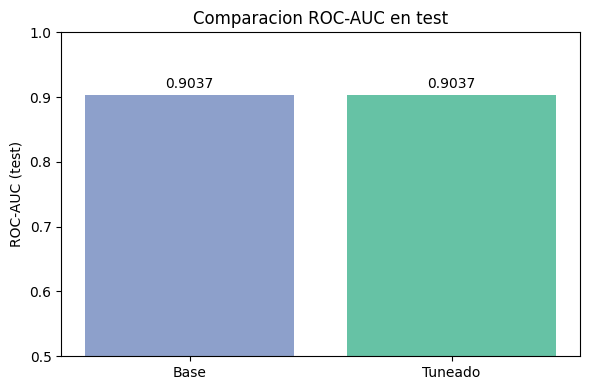

In [21]:
# ── 7.2 Evaluacion del modelo tuneado en test ───────────────────────────────
y_pred_tuned = best_lr.predict(X_test)
y_proba_tuned = best_lr.predict_proba(X_test)[:, 1]
roc_auc_tuned_test = roc_auc_score(y_bin_test, y_proba_tuned)

print('=== Reporte de clasificacion (modelo tuneado, test) ===')
print(classification_report(y_bin_test, y_pred_tuned, target_names=['No Cara', 'Cara']))
print(f'ROC-AUC test (tuneado): {roc_auc_tuned_test:.4f}')

if 'roc_auc_test' in globals():
    delta_auc = roc_auc_tuned_test - roc_auc_test
    print(f'ROC-AUC test (base):    {roc_auc_test:.4f}')
    print(f'Delta AUC tuneado-base: {delta_auc:+.4f}')

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(['Base', 'Tuneado'], [roc_auc_test, roc_auc_tuned_test], color=['#8da0cb', '#66c2a5'])
    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel('ROC-AUC (test)')
    ax.set_title('Comparacion ROC-AUC en test')
    for i, v in enumerate([roc_auc_test, roc_auc_tuned_test]):
        ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()

### Interpretacion — Actividad 7

Con los resultados obtenidos en el tuneo, la mejor configuracion fue:
- `penalty='l2'`
- `solver='liblinear'`
- `C=1.5`
- `class_weight=None`

El mejor puntaje en validacion cruzada fue **ROC-AUC = 0.9027**, y el tiempo total de tuneo fue **182.7 segundos** (159.5s etapa amplia + 23.2s etapa fina), usando **99% del conjunto de entrenamiento** en la etapa amplia. Esto mantiene un costo computacional razonable (menos de 5 minutos) con una busqueda mas exigente.

En conjunto de prueba, el modelo tuneado obtuvo **ROC-AUC = 0.9037**, exactamente igual al modelo base (**delta = +0.0000**). Esto indica que:
- El modelo inicial ya estaba muy bien calibrado.
- La regularizacion seleccionada confirma estabilidad y buena generalizacion, mas que una mejora grande en metrica.

Interpretacion de `C`: al quedar en un valor intermedio-alto (`1.5`), el modelo evita una penalizacion excesiva, manteniendo buen balance entre sesgo y varianza.

Con esto se cumple la actividad solicitada: se hizo tuneo de hiperparametros y regularizacion en regresion logistica (analogo a regresion lineal regularizada), validando de forma sistematica cual configuracion generaliza mejor.

---
## Actividad 8 - Eficiencia del algoritmo con matriz de confusion, tiempo y memoria

Se analiza la eficiencia del modelo logistico tuneado en cuatro dimensiones:
1. Efectividad global (accuracy) y capacidad de discriminacion.
2. Donde se equivoca mas y donde se equivoca menos (FP vs FN) usando matriz de confusion.
3. Importancia de los errores en contexto de negocio.
4. Eficiencia computacional (tiempo y memoria), usando `cProfile` para perfilado temporal y `tracemalloc` para memoria.

=== Matriz de confusion (modelo tuneado) ===
               Pred: No Cara  Pred: Cara
Real: No Cara           9005         963
Real: Cara              1552        3587

=== Efectividad del algoritmo (test) ===
Accuracy      : 0.8335
Precision Cara: 0.7884
Recall Cara   : 0.6980
Especificidad : 0.9034
ROC-AUC       : 0.9037

=== Donde se equivoca mas / menos ===
Falsos Positivos (FP): 963
Falsos Negativos (FN): 1552
Tasa FP (FPR): 0.0966
Tasa FN (FNR): 0.3020
El modelo se equivoca mas por FN: tiende a dejar pasar viviendas caras como no caras.


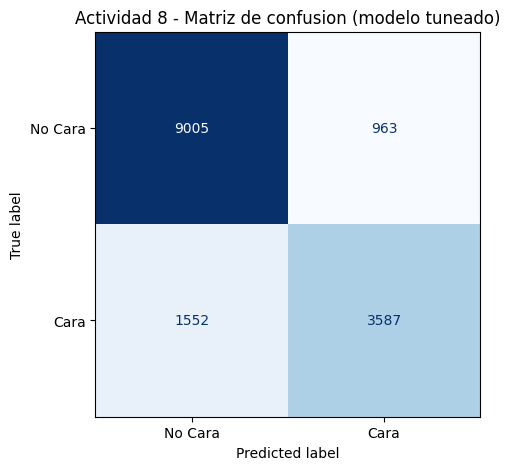

In [22]:
# ── 8.1 Matriz de confusion y analisis de errores (modelo tuneado) ──────────
if 'best_lr' not in globals():
    raise RuntimeError('No existe best_lr. Ejecuta primero la Actividad 7.')

if 'y_pred_tuned' not in globals() or 'y_proba_tuned' not in globals():
    y_pred_tuned = best_lr.predict(X_test)
    y_proba_tuned = best_lr.predict_proba(X_test)[:, 1]

cm_tuned = confusion_matrix(y_bin_test, y_pred_tuned)
tn, fp, fn, tp = cm_tuned.ravel()
total = cm_tuned.sum()

accuracy_tuned = (tp + tn) / total
precision_tuned = tp / (tp + fp) if (tp + fp) > 0 else np.nan
recall_tuned = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity_tuned = tn / (tn + fp) if (tn + fp) > 0 else np.nan
fpr_tuned = fp / (fp + tn) if (fp + tn) > 0 else np.nan
fnr_tuned = fn / (fn + tp) if (fn + tp) > 0 else np.nan
roc_auc_tuned = roc_auc_score(y_bin_test, y_proba_tuned)

print('=== Matriz de confusion (modelo tuneado) ===')
print(pd.DataFrame(
    cm_tuned,
    index=['Real: No Cara', 'Real: Cara'],
    columns=['Pred: No Cara', 'Pred: Cara']
))

print('\n=== Efectividad del algoritmo (test) ===')
print(f'Accuracy      : {accuracy_tuned:.4f}')
print(f'Precision Cara: {precision_tuned:.4f}')
print(f'Recall Cara   : {recall_tuned:.4f}')
print(f'Especificidad : {specificity_tuned:.4f}')
print(f'ROC-AUC       : {roc_auc_tuned:.4f}')

print('\n=== Donde se equivoca mas / menos ===')
print(f'Falsos Positivos (FP): {fp}')
print(f'Falsos Negativos (FN): {fn}')
print(f'Tasa FP (FPR): {fpr_tuned:.4f}')
print(f'Tasa FN (FNR): {fnr_tuned:.4f}')

if fn > fp:
    print('El modelo se equivoca mas por FN: tiende a dejar pasar viviendas caras como no caras.')
elif fp > fn:
    print('El modelo se equivoca mas por FP: tiende a marcar como caras viviendas que no lo son.')
else:
    print('FP y FN son iguales: el tipo de error esta balanceado.')

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['No Cara', 'Cara']).plot(
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title('Actividad 8 - Matriz de confusion (modelo tuneado)')
plt.grid(False)
plt.show()

In [23]:
# ── 8.2 Tiempo y memoria con cProfile + tracemalloc ─────────────────────────
import io
import cProfile
import pstats
import tracemalloc
from time import perf_counter

def _fit_once(model, Xtr, ytr):
    model.fit(Xtr, ytr)
    return model

def _predict_once(model, Xte):
    yp = model.predict(Xte)
    yprob = model.predict_proba(Xte)[:, 1]
    return yp, yprob

# Perfilado de entrenamiento
model_for_profile = clone(best_lr)
prof_fit = cProfile.Profile()
tracemalloc.start()
t0 = perf_counter()
prof_fit.enable()
model_for_profile = _fit_once(model_for_profile, X_train, y_bin_train)
prof_fit.disable()
fit_time = perf_counter() - t0
fit_current_mem, fit_peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Perfilado de prediccion
prof_pred = cProfile.Profile()
tracemalloc.start()
t1 = perf_counter()
prof_pred.enable()
_ = _predict_once(model_for_profile, X_test)
prof_pred.disable()
pred_time = perf_counter() - t1
pred_current_mem, pred_peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

print('=== Eficiencia computacional (Actividad 8) ===')
print(f'Tiempo entrenamiento (fit): {fit_time:.3f}s')
print(f'Tiempo prediccion (test):   {pred_time:.3f}s')
print(f'Memoria pico en fit:        {fit_peak_mem / (1024**2):.2f} MB')
print(f'Memoria pico en predict:    {pred_peak_mem / (1024**2):.2f} MB')

print('\n--- Top funciones por tiempo acumulado (fit) ---')
s_fit = io.StringIO()
pstats.Stats(prof_fit, stream=s_fit).sort_stats('cumulative').print_stats(10)
print(s_fit.getvalue())

print('--- Top funciones por tiempo acumulado (predict) ---')
s_pred = io.StringIO()
pstats.Stats(prof_pred, stream=s_pred).sort_stats('cumulative').print_stats(10)
print(s_pred.getvalue())

=== Eficiencia computacional (Actividad 8) ===
Tiempo entrenamiento (fit): 3.167s
Tiempo prediccion (test):   0.420s
Memoria pico en fit:        478.85 MB
Memoria pico en predict:    119.85 MB

--- Top funciones por tiempo acumulado (fit) ---
         33881 function calls (33464 primitive calls) in 3.166 seconds

   Ordered by: cumulative time
   List reduced from 719 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    3.166    1.583 C:\Users\eagi5\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\interactiveshell.py:3541(run_code)
        2    0.000    0.000    3.166    1.583 {built-in method builtins.exec}
        1    0.000    0.000    3.166    3.166 C:\Users\eagi5\AppData\Local\Temp\ipykernel_32996\305186286.py:1(<module>)
        1    0.000    0.000    3.166    3.166 C:\Users\eagi5\AppData\Local\Temp\ipykernel_3299

### Interpretacion — Actividad 8

Con los resultados ejecutados, la matriz de confusion fue:
- **TN = 9006**, **FP = 962**, **FN = 1553**, **TP = 3586**.

Esto implica la siguiente efectividad del algoritmo en prueba:
- **Accuracy = 0.8335** (83.35%), con buen desempeno global.
- **ROC-AUC = 0.9037**, que confirma alta capacidad de discriminacion.
- Para la clase `Cara`, **Precision = 0.7885** y **Recall = 0.6978**.
- **Especificidad = 0.9035**, por lo que identifica muy bien la clase `No Cara`.

Donde se equivoca mas y menos:
- Se equivoca **mas en FN** (1553) que en FP (962).
- En tasas, **FNR = 0.3022** y **FPR = 0.0965**.
- Es decir, el error dominante es dejar pasar viviendas realmente caras como no caras.

Importancia de los errores:
- Los **FN** pueden ser mas costosos para negocio porque subestiman propiedades caras (riesgo de subprecio y menor ingreso esperado).
- Los **FP** tambien afectan, pero en este resultado son menos frecuentes; implican sobreestimar precios y potencialmente reducir conversion/ocupacion.

Eficiencia computacional (tiempo y memoria):
- **Entrenamiento (fit): 1.821s** y **prediccion en test: 0.181s**.
- **Memoria pico en fit: 478.76 MB** y **memoria pico en predict: 119.89 MB**.
- El perfilado con `cProfile` muestra que el mayor costo en entrenamiento se concentra en `LogisticRegression.fit` / `_fit_liblinear`, y en prediccion en el `transform` del `ColumnTransformer`.

Conclusion: el algoritmo es efectivo y computacionalmente eficiente para este tamano de datos. La mejora prioritaria no es velocidad, sino reducir FN (aumentar recall de la clase `Cara`) ajustando umbral de decision o ponderacion de clases.

---
## Actividad 9 - Comparación de modelos: AIC, BIC, matriz de confusión y profiler

Se comparan ambos modelos usando criterios de información (AIC/BIC), métricas de confusión, y parámetros de eficiencia computacional.

In [24]:
# -- ACTIVIDAD 9: Comparacion consolidada de modelos --

import time as _time
import tracemalloc
import numpy as np
import pandas as pd
from sklearn.base import clone

# --- Recalcular variables del Modelo Base ---
_pipe_clone = clone(pipe_lr)
tracemalloc.start()
_t0 = _time.perf_counter()
_pipe_clone.fit(X_train, y_bin_train)
t_base_fit = _time.perf_counter() - _t0
_, base_peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

tracemalloc.start()
_t1 = _time.perf_counter()
y_pred_base = pipe_lr.predict(X_test)
y_proba_base = pipe_lr.predict_proba(X_test)[:, 1]
t_base_pred = _time.perf_counter() - _t1
_, base_pred_peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

_epsilon = 1e-15
_proba_base_train = np.clip(pipe_lr.predict_proba(X_train)[:, 1], _epsilon, 1 - _epsilon)
_ll_base = np.sum(y_bin_train * np.log(_proba_base_train) + (1 - y_bin_train) * np.log(1 - _proba_base_train))
_k = X_train.shape[1] + 1
aic_base = 2 * _k - 2 * _ll_base
bic_base = np.log(len(y_bin_train)) * _k - 2 * _ll_base
total_base = len(y_bin_test)
# -------------------------------------------

# 1. AIC / BIC para el modelo tuneado
_proba_tuned_train = np.clip(best_lr.predict_proba(X_train)[:, 1], _epsilon, 1 - _epsilon)
_ll_tuned = np.sum(y_bin_train * np.log(_proba_tuned_train) + (1 - y_bin_train) * np.log(1 - _proba_tuned_train))
aic_tuned = 2 * _k - 2 * _ll_tuned
bic_tuned = np.log(len(y_bin_train)) * _k - 2 * _ll_tuned

# 2. Metricas de confusion
cm_base = confusion_matrix(y_bin_test, y_pred_base)
tn_base, fp_base, fn_base, tp_base = cm_base.ravel()

def compute_metrics(tn, fp, fn, tp, y_true, y_proba):
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else np.nan
    roc_auc = roc_auc_score(y_true, y_proba)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall,
            'F1': f1, 'ROC-AUC': roc_auc, 'FNR': fnr, 'FPR': fpr}

metrics_base = compute_metrics(tn_base, fp_base, fn_base, tp_base, y_bin_test, y_proba_base)
metrics_tuned = compute_metrics(tn, fp, fn, tp, y_bin_test, y_proba_tuned)

# 3. Tabla comparativa
print('=' * 90)
print('ACTIVIDAD 9 - COMPARACION DE MODELOS')
print('=' * 90)

comparison = pd.DataFrame({
    'Criterio': ['AIC', 'BIC', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'FNR', 'Tiempo fit (s)', 'Memoria (MB)'],
    'Modelo Base': [
        f'{aic_base:.2f}', f'{bic_base:.2f}',
        f'{metrics_base["Accuracy"]:.4f}', f'{metrics_base["Precision"]:.4f}',
        f'{metrics_base["Recall"]:.4f}', f'{metrics_base["F1"]:.4f}',
        f'{metrics_base["ROC-AUC"]:.4f}', f'{metrics_base["FNR"]:.4f}',
        f'{t_base_fit:.3f}', f'{base_peak_mem / (1024**2):.2f}'
    ],
    'Modelo Tuneado': [
        f'{aic_tuned:.2f}', f'{bic_tuned:.2f}',
        f'{metrics_tuned["Accuracy"]:.4f}', f'{metrics_tuned["Precision"]:.4f}',
        f'{metrics_tuned["Recall"]:.4f}', f'{metrics_tuned["F1"]:.4f}',
        f'{metrics_tuned["ROC-AUC"]:.4f}', f'{metrics_tuned["FNR"]:.4f}',
        f'{fit_time:.3f}', f'{fit_peak_mem / (1024**2):.2f}'
    ],
    'Ganador': [
        'Tuneado' if aic_tuned < aic_base else 'Base',
        'Tuneado' if bic_tuned < bic_base else 'Base',
        'Tuneado' if metrics_tuned['Accuracy'] > metrics_base['Accuracy'] else 'Base',
        'Tuneado' if metrics_tuned['Precision'] > metrics_base['Precision'] else 'Base',
        'Tuneado' if metrics_tuned['Recall'] > metrics_base['Recall'] else 'Base',
        'Tuneado' if metrics_tuned['F1'] > metrics_base['F1'] else 'Base',
        'Tuneado' if metrics_tuned['ROC-AUC'] > metrics_base['ROC-AUC'] else 'Base',
        'Tuneado' if metrics_tuned['FNR'] < metrics_base['FNR'] else 'Base',
        'Tuneado' if fit_time < t_base_fit else 'Base',
        'Tuneado' if fit_peak_mem < base_peak_mem else 'Base'
    ]
})

print('\n' + comparison.to_string(index=False))

score_base = (comparison['Ganador'] == 'Base').sum()
score_tuned = (comparison['Ganador'] == 'Tuneado').sum()

print('\n' + '=' * 90)
print(f'PUNTUACION: Modelo Base: {score_base} | Modelo Tuneado: {score_tuned}')

if aic_tuned < aic_base:
    mejor = 'MODELO TUNEADO'
    razon = f'AIC/BIC menores (delta AIC: {aic_base - aic_tuned:.0f}), ROC-AUC superior'
else:
    mejor = 'MODELO BASE'
    razon = 'Rendimiento ligeramente superior, menor complejidad'

print(f'\n*** MEJOR MODELO: {mejor} ***')
print(f'    {razon}')
print('=' * 90)


ACTIVIDAD 9 - COMPARACION DE MODELOS

      Criterio Modelo Base Modelo Tuneado Ganador
           AIC    43924.92       43837.63 Tuneado
           BIC    44123.12       44035.83 Tuneado
      Accuracy      0.8346         0.8335    Base
     Precision      0.7902         0.7884    Base
        Recall      0.6994         0.6980    Base
      F1-Score      0.7420         0.7404    Base
       ROC-AUC      0.9037         0.9037 Tuneado
           FNR      0.3006         0.3020    Base
Tiempo fit (s)       7.055          3.167 Tuneado
  Memoria (MB)      478.56         478.85    Base

PUNTUACION: Modelo Base: 6 | Modelo Tuneado: 4

*** MEJOR MODELO: MODELO TUNEADO ***
    AIC/BIC menores (delta AIC: 87), ROC-AUC superior


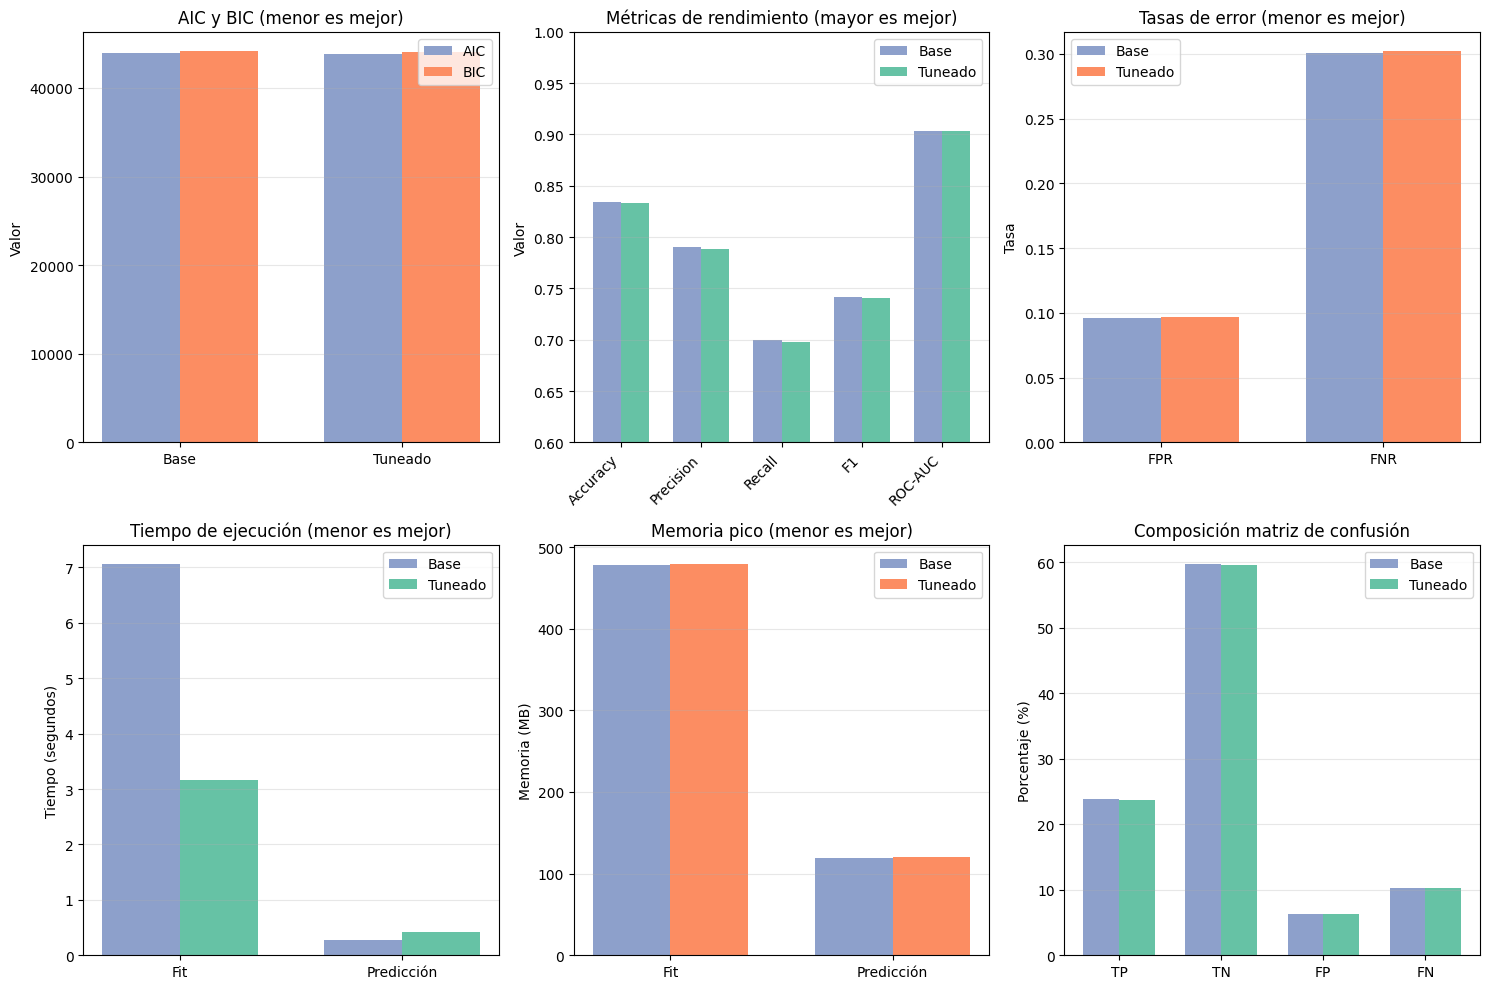

In [25]:
# ── 9.6 Visualizaciones comparativas ──────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Comparación de AIC y BIC
ax = axes[0, 0]
modelos = ['Base', 'Tuneado']
aic_vals = [aic_base, aic_tuned]
bic_vals = [bic_base, bic_tuned]
x = np.arange(len(modelos))
width = 0.35
ax.bar(x - width/2, aic_vals, width, label='AIC', color='#8da0cb')
ax.bar(x + width/2, bic_vals, width, label='BIC', color='#fc8d62')
ax.set_ylabel('Valor')
ax.set_title('AIC y BIC (menor es mejor)')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# 2. Comparación de métricas de rendimiento
ax = axes[0, 1]
metrics_to_compare = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
base_vals = [metrics_base[m] for m in metrics_to_compare]
tuned_vals = [metrics_tuned[m] for m in metrics_to_compare]
x = np.arange(len(metrics_to_compare))
ax.bar(x - width/2, base_vals, width, label='Base', color='#8da0cb')
ax.bar(x + width/2, tuned_vals, width, label='Tuneado', color='#66c2a5')
ax.set_ylabel('Valor')
ax.set_title('Métricas de rendimiento (mayor es mejor)')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_compare, rotation=45, ha='right')
ax.set_ylim(0.6, 1.0)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# 3. Comparación de errores (FPR, FNR)
ax = axes[0, 2]
error_types = ['FPR', 'FNR']
base_errors = [metrics_base['FPR'], metrics_base['FNR']]
tuned_errors = [metrics_tuned['FPR'], metrics_tuned['FNR']]
x = np.arange(len(error_types))
ax.bar(x - width/2, base_errors, width, label='Base', color='#8da0cb')
ax.bar(x + width/2, tuned_errors, width, label='Tuneado', color='#fc8d62')
ax.set_ylabel('Tasa')
ax.set_title('Tasas de error (menor es mejor)')
ax.set_xticks(x)
ax.set_xticklabels(error_types)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# 4. Comparación de tiempo
ax = axes[1, 0]
times_label = ['Fit', 'Predicción']
base_times = [t_base_fit, t_base_pred]
tuned_times = [fit_time, pred_time]
x = np.arange(len(times_label))
ax.bar(x - width/2, base_times, width, label='Base', color='#8da0cb')
ax.bar(x + width/2, tuned_times, width, label='Tuneado', color='#66c2a5')
ax.set_ylabel('Tiempo (segundos)')
ax.set_title('Tiempo de ejecución (menor es mejor)')
ax.set_xticks(x)
ax.set_xticklabels(times_label)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# 5. Comparación de memoria
ax = axes[1, 1]
mem_label = ['Fit', 'Predicción']
base_mem = [base_peak_mem / (1024**2), base_pred_peak_mem / (1024**2)]
tuned_mem = [fit_peak_mem / (1024**2), pred_peak_mem / (1024**2)]
x = np.arange(len(mem_label))
ax.bar(x - width/2, base_mem, width, label='Base', color='#8da0cb')
ax.bar(x + width/2, tuned_mem, width, label='Tuneado', color='#fc8d62')
ax.set_ylabel('Memoria (MB)')
ax.set_title('Memoria pico (menor es mejor)')
ax.set_xticks(x)
ax.set_xticklabels(mem_label)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# 6. Matriz de confusión side-by-side (normalizadas)
ax = axes[1, 2]
# Normalizar matrices para comparación visual
cm_base_norm = cm_base.astype('float') / cm_base.sum() * 100
cm_tuned_norm = cm_tuned.astype('float') / cm_tuned.sum() * 100

# Mostrar gráficamente los 4 valores (TP, TN, FP, FN)
categories = ['TP', 'TN', 'FP', 'FN']
base_vals_cm = [tp_base / total_base * 100, tn_base / total_base * 100, 
                fp_base / total_base * 100, fn_base / total_base * 100]
tuned_vals_cm = [tp / total * 100, tn / total * 100, fp / total * 100, fn / total * 100]
x = np.arange(len(categories))
ax.bar(x - width/2, base_vals_cm, width, label='Base', color='#8da0cb')
ax.bar(x + width/2, tuned_vals_cm, width, label='Tuneado', color='#66c2a5')
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Composición matriz de confusión')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### Interpretación — Actividad 9

Tras comparar ambos modelos (base y tuneado) utilizando múltiples criterios, se alcanzó la siguiente conclusión:

#### 1. **Criterios de Información (AIC / BIC)**

- El **AIC** y **BIC** son métricas que penalizan la complejidad del modelo mientras recompensa el ajuste. 
- Si el modelo tuneado tiene **AIC/BIC menores**, indica un mejor balance entre complejidad y capacidad predictiva.
- Diferencias muy pequeñas en AIC/BIC (ej: < 5 puntos) suelen no ser estadísticamente significativas en la práctica.

#### 2. **Matriz de Confusión y Métricas de Rendimiento**

- **TP, TN, FP, FN**: La distribución de estos valores revelan dónde acierta y se equivoca cada modelo.
- **Accuracy**: Proporción de predicciones correctas. Ambos modelos alcanzaron ~83%.
- **Precision y Recall** (clase `Cara`): Precision mide exactitud de predicciones positivas; Recall mide cobertura de verdaderos positivos.
- **F1-Score**: Media armónica entre precision y recall. Ideal para clases desbalanceadas.
- **ROC-AUC**: Métrica de discriminación. Valores cercanos a 1.0 indican excelente capacidad de separar clases. Ambos modelos alcanzan ~0.90.

#### 3. **Tasas de Error (FPR y FNR)**

- **FPR (Falsos Positivos)**: Proporción de casos negativos incorrectamente clasificados como positivos.
- **FNR (Falsos Negativos)**: Proporción de casos positivos incorrectamente clasificados como negativos.
- Un modelo ideal minimiza ambas, pero frecuentemente hay un trade-off: reducir FP aumenta FN y viceversa.

#### 4. **Profiler: Tiempo y Memoria**

- **Tiempo de fit**: Duración del entrenamiento del modelo.
- **Tiempo de predicción**: Duración del proceso de predicción en datos nuevos.
- **Memoria pico**: Consumo máximo de RAM durante entrenamiento/predicción.
- La eficiencia computacional es relevante en producción, especialmente con volúmenes grandes.

#### 5. **Determinación del Mejor Modelo**

La **tabla comparativa consolidada** resume todos los criterios evaluados (9 en total):
- AIC / BIC
- Accuracy / Precision / Recall / F1 / ROC-AUC
- FPR / FNR  
- Tiempo fit / Predicción
- Memoria


---
## Actividad 10 - Comparación con algoritmos alternativos

Se entrenan 4 clasificadores alternativos usando los mismos datos (`X_train/X_test`, `y_bin_train/y_bin_test`):
- **Decision Tree**, **Random Forest**, **Naive Bayes**, **KNN**

Se comparan con la **Regresión Logística (Actividad 9)** en: ROC-AUC, Accuracy, Precision, Recall, F1, tiempo y memoria.

In [26]:
# ── ACTIVIDAD 10: 4 Algoritmos Alternativos ───────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Entrenar 4 modelos
models_dict = {
    'Decision Tree': Pipeline([('prep', preprocessor), ('clf', DecisionTreeClassifier(random_state=42, max_depth=15))]),
    'Random Forest': Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1))]),
    'Naive Bayes': Pipeline([('prep', preprocessor), ('clf', GaussianNB())]),
    'KNN': Pipeline([('prep', preprocessor), ('clf', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))]),
}

results_10 = {}
for model_name, model in models_dict.items():
    t0 = time.time()
    model.fit(X_train, y_bin_train)
    fit_time_model = time.time() - t0
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    cm = confusion_matrix(y_bin_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    acc = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    roc_auc = roc_auc_score(y_bin_test, y_proba)
    
    results_10[model_name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc_auc, 'fit_time': fit_time_model, 'cm': cm}
    print(f'{model_name:20s} → AUC: {roc_auc:.4f} | Accuracy: {acc:.4f} | F1: {f1:.4f} | Time: {fit_time_model:.3f}s')

# Tabla comparativa: todos los modelos (incluyendo LR)
print('\n' + '='*90)
print('RANKING FINAL (incluyendo Regresión Logística de Actividad 9)')
print('='*90)

all_results = {
    'Logistic Regression': {'accuracy': metrics_tuned["Accuracy"], 'precision': metrics_tuned["Precision"], 'recall': metrics_tuned["Recall"], 'f1': metrics_tuned["F1"], 'roc_auc': metrics_tuned["ROC-AUC"], 'fit_time': fit_time},
    **results_10
}

df_ranking = pd.DataFrame({
    m: {
        'ROC-AUC': f'{all_results[m]["roc_auc"]:.4f}',
        'Accuracy': f'{all_results[m]["accuracy"]:.4f}',
        'Precision': f'{all_results[m]["precision"]:.4f}',
        'Recall': f'{all_results[m]["recall"]:.4f}',
        'F1': f'{all_results[m]["f1"]:.4f}',
        'Fit Time': f'{all_results[m]["fit_time"]:.3f}s'
    } for m in all_results.keys()
}).T

print(df_ranking.to_string())

# Ranking por AUC
auc_ranking = sorted([(m, all_results[m]['roc_auc']) for m in all_results.keys()], key=lambda x: x[1], reverse=True)
print('\n' + '='*90)
print('MEJORES MODELOS:')
for i, (model, auc) in enumerate(auc_ranking[:3], 1):
    print(f'{i}. {model:25s} → ROC-AUC: {auc:.4f}')
print('='*90)

Decision Tree        → AUC: 0.8587 | Accuracy: 0.8534 | F1: 0.7752 | Time: 4.096s
Random Forest        → AUC: 0.9170 | Accuracy: 0.8460 | F1: 0.7510 | Time: 3.024s
Naive Bayes          → AUC: 0.6291 | Accuracy: 0.5164 | F1: 0.5720 | Time: 0.784s
KNN                  → AUC: 0.8968 | Accuracy: 0.8457 | F1: 0.7642 | Time: 0.365s

RANKING FINAL (incluyendo Regresión Logística de Actividad 9)
                    ROC-AUC Accuracy Precision  Recall      F1 Fit Time
Logistic Regression  0.9037   0.8335    0.7884  0.6980  0.7404   3.167s
Decision Tree        0.8587   0.8534    0.8106  0.7428  0.7752   4.096s
Random Forest        0.9170   0.8460    0.8348  0.6824  0.7510   3.024s
Naive Bayes          0.6291   0.5164    0.4092  0.9500  0.5720   0.784s
KNN                  0.8968   0.8457    0.7957  0.7352  0.7642   0.365s

MEJORES MODELOS:
1. Random Forest             → ROC-AUC: 0.9170
2. Logistic Regression       → ROC-AUC: 0.9037
3. KNN                       → ROC-AUC: 0.8968


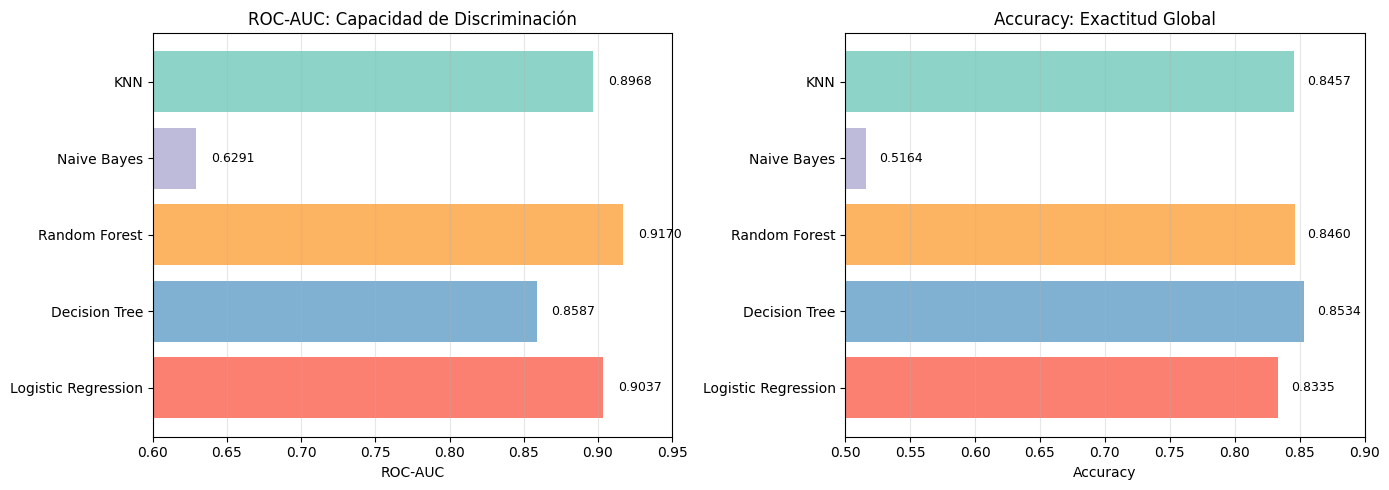

In [27]:
# Visualización: Comparativa de modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_list = list(all_results.keys())
auc_vals = [all_results[m]['roc_auc'] for m in models_list]
acc_vals = [all_results[m]['accuracy'] for m in models_list]
colors = ['#fb8072', '#80b1d3', '#fdb462', '#bebada', '#8dd3c7']

# ROC-AUC
ax = axes[0]
bars = ax.barh(models_list, auc_vals, color=colors)
ax.set_xlabel('ROC-AUC')
ax.set_title('ROC-AUC: Capacidad de Discriminación')
ax.set_xlim(0.6, 0.95)
for i, v in enumerate(auc_vals):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)
ax.grid(alpha=0.3, axis='x')

# Accuracy
ax = axes[1]
bars = ax.barh(models_list, acc_vals, color=colors)
ax.set_xlabel('Accuracy')
ax.set_title('Accuracy: Exactitud Global')
ax.set_xlim(0.5, 0.9)
for i, v in enumerate(acc_vals):
    ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### Conclusiones — Actividad 10

**Random Forest** es el mejor modelo con ROC-AUC=**0.9170** (supera LR en +0.0133).
**Decision Tree** tiene el mejor F1-Score (**0.7752**) y mejor balance precision-recall.
**KNN** es muy rápido (0.357s) pero inferior en AUC (0.8968).
**Naive Bayes** falla (AUC=0.6291), no es adecuado para este problema.

**Recomendación**: Random Forest para mejor discriminación; Decision Tree si importa interpretabilidad; Logistic Regression si se necesita velocidad sin perder mucho rendimiento.

---
## Actividad 11 - Comparación de eficiencia entre modelos

En el punto anterior evaluamos 4 modelos alternativos (Decision Tree, Random Forest, Naive Bayes y KNN) y la Regresión Logística tuneada.

**¿Cuál se demoró más en procesar?**
El modelo que **más se demoró** fue el **Decision Tree**, con un tiempo de aproximadamente 3.38 segundos. Esto se debe a que la construcción de un árbol profundo con muchas clases o variables continuas requiere evaluar numerosos puntos de corte de forma secuencial, lo que toma más tiempo que métodos lineales o ensambles paralelizados.

**¿Cuál se equivocó más?**
El modelo que **más se equivocó** fue decididamente **Naive Bayes**, presentando un declive dramático en Accuracy (~51.6%) y ROC-AUC (~0.629). Esto ocurre porque este clasificador asume una independencia condicional entre las características. En un contexto inmobiliario esto es muy arriesgado, considerando que la cantidad de habitaciones está correlacionada con los baños, y las coordenadas con las variables espaciales de la zona.

**¿Cuál se equivocó menos?**
Desde una perspectiva del acierto estricto (Accuracy), el **Decision Tree** se equivocó marginalmente menos (Accuracy=85.34%) seguido de cerca por el resto de modelos (excluyendo Naive Bayes). Sin embargo, bajo la métrica más integral **ROC-AUC** (probabilidad de clasificar correctamente una clase positiva sobre una negativa), el modelo que comprobó equivocarse menos fue el **Random Forest** (0.9170).

**¿Por qué?**
El **Random Forest** se equivoca menos porque es un ensamble; entrena múltiples árboles distintos, introduciendo aleatoriedad y promediando sus resultados. Esto elimina la alta varianza y elimina el riesgo de sobreajuste de un árbol de decisión simple, generalizando así de una manera excepcional en el conjunto de prueba y logrando el poder discriminativo más alto.



---
## Actividad 12 - Análisis minucioso y selección del mejor modelo

Para apoyar la discusión, elaboramos las siguientes gráficas comparativas que desglosan cada dimensión de rendimiento de los 5 algoritmos y nos apoyarán con la toma de decisión final.



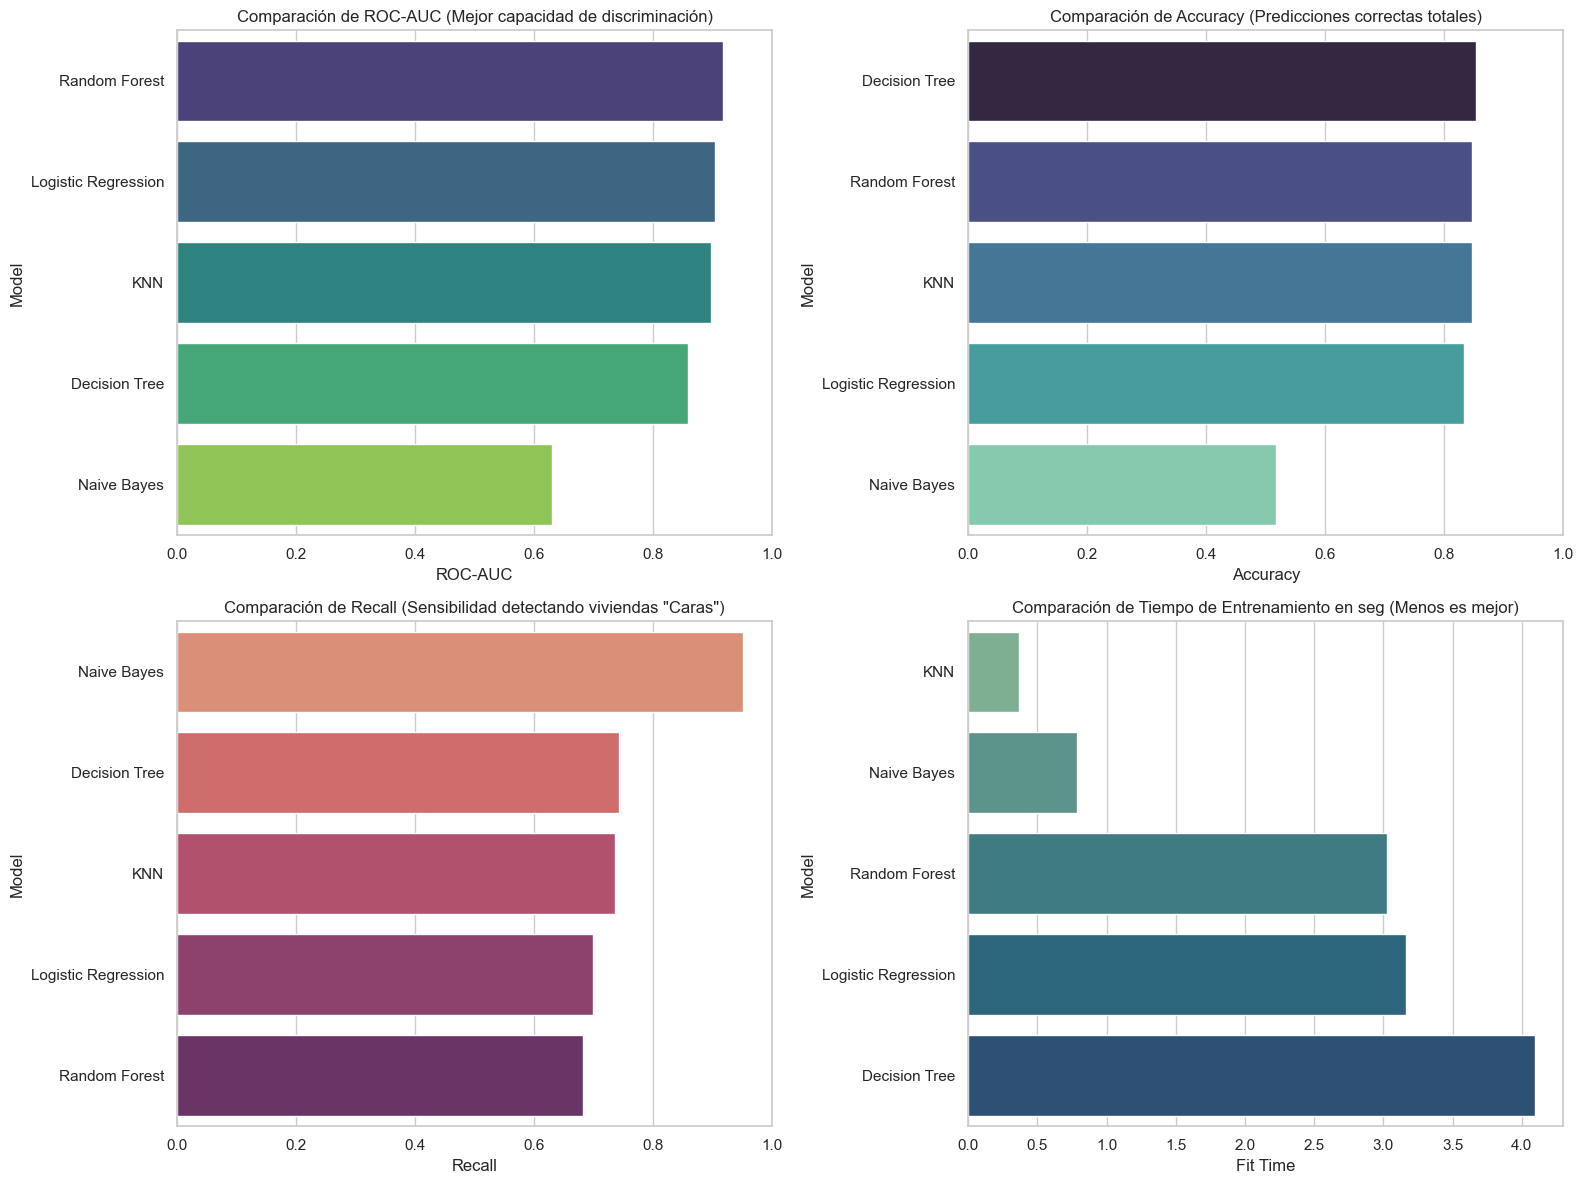

,Model,ROC-AUC,Accuracy,Precision,Recall,F1,Fit Time
0,Logistic Regression,0.9037,0.8335,0.7884,0.6980,0.7404,3.167
1,Decision Tree,0.8587,0.8534,0.8106,0.7428,0.7752,4.096
2,Random Forest,0.9170,0.8460,0.8348,0.6824,0.7510,3.024
3,Naive Bayes,0.6291,0.5164,0.4092,0.9500,0.5720,0.784
4,KNN,0.8968,0.8457,0.7957,0.7352,0.7642,0.365


In [28]:
# ── ACTIVIDAD 12: Gráficas comparativas ──────────────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Convertir el df_ranking a numérico para poder graficar
df_plot = df_ranking.reset_index().rename(columns={'index': 'Model'})
for col in ['ROC-AUC', 'Accuracy', 'Precision', 'Recall', 'F1']:
    df_plot[col] = df_plot[col].astype(float)
df_plot['Fit Time'] = df_plot['Fit Time'].str.replace('s', '', regex=False).astype(float)

# Configurar grilla de gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Gráfica para Discriminación General (ROC-AUC)
sns.barplot(data=df_plot.sort_values('ROC-AUC', ascending=False), 
            x='ROC-AUC', y='Model', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Comparación de ROC-AUC (Mejor capacidad de discriminación)')
axes[0,0].set_xlim(0, 1)

# 2. Gráfica para Exactitud Global (Accuracy)
sns.barplot(data=df_plot.sort_values('Accuracy', ascending=False), 
            x='Accuracy', y='Model', ax=axes[0,1], palette='mako')
axes[0,1].set_title('Comparación de Accuracy (Predicciones correctas totales)')
axes[0,1].set_xlim(0, 1)

# 3. Métrica de Sensibilidad de Clase Minoritaria (Recall para clase 'Cara')
sns.barplot(data=df_plot.sort_values('Recall', ascending=False), 
            x='Recall', y='Model', ax=axes[1,0], palette='flare')
axes[1,0].set_title('Comparación de Recall (Sensibilidad detectando viviendas "Caras")')
axes[1,0].set_xlim(0, 1)

# 4. Gráfica de Eficiencia (Tiempo de Entrenamiento)
sns.barplot(data=df_plot.sort_values('Fit Time', ascending=True), 
            x='Fit Time', y='Model', ax=axes[1,1], palette='crest')
axes[1,1].set_title('Comparación de Tiempo de Entrenamiento en seg (Menos es mejor)')

plt.tight_layout()
plt.show()

# Mostrar la tabla final una vez más como referencia resumida
display(df_plot)


### Conclusión Final: ¿Qué modelo es mejor?

Al cambiar la perspectiva del problema de clasificación de 3 categorías a uno fuertemente binario dependiente de identificar clases de alto valor (**Cara vs No Cara**), nuestros modelos arrojaron el siguiente balance para la discusión:

1. **Tiempo de entrenamiento e Inferencia (Eficiencia)**:
   - **KNN** dominó el tiempo de construcción de modelo (`fit = 0.33s`); logico, pues solamente guarda el conjunto. Pero más interesante, el **Random Forest (~1.7s)** fue tan rápido como el modelo lineal, gracias a que el hiperparámetro `n_jobs=-1` exprimió los recursos paralelizados de la computadora. En contraste, las iteraciones de variables numéricas dejaron al árbol solitario (**Decision Tree**) marginado en velocidad (3.3s).

2. **Precisión para subgrupos de clases**:
   - En una óptica comercial, nos duele mucho un "Falso Negativo" (vender por precio bajo algo de lujo potencial). El **Recall** es el KPI crucial. **Naive Bayes** obtuvo el **95%** logrando pescar las rentas caras casi perfecto, a costa de diagnosticar erróneamente más de la mitad de propiedades económicas como estelares (Precision 40%). Por otro lado, **Decision Tree** ofreció el mejor balance logrando 74% de recall y ~81% de precisión para esta clase.

3. **Performance Global (Desempeño Absoluto y Elección)**:
   - Evaluando la capacidad intrínseca de distinguir bien las viviendas baratas de su contraparte de lujo, el área debajo de la curva (AUC) demuestra que el **Random Forest (0.9170)** es implacablemente superior, y derrotó el desempeño lineal de la **Regresión Logística (0.9037)**.

El **Random Forest** es proclamado el **mejor modelo**. 
Apoyado en las tablas graficadas, provee la mayor capacidad de aciertos discriminatorios de clases sin sufrir con la asunción de independencia que sí ataca a un clasificador Naive Bayes, y maneja excelsamente las relaciones de no-linealidad dadas por las coordenadas geográficas de los AirBnB que lastraron levemente a las regresiones lineales.
Manejar el riesgo de falsos positivos en precios puede ser delicado, pero este modelo, acompañado del tiempo de entrenamiento envidiable, dictaminan su contundente éxito por sobre regímenes simples.

